In [1]:
import numpy as np
import pandas
import geopandas
import warnings
warnings.filterwarnings("ignore")
from matplotlib import pyplot as plt
from time import time
from pprint import pprint
from shapely import affinity
from shapely.ops import unary_union
import os
thisyear = 2025
the_epsg = 3424   # New Jersey 3424
equalareacrs = "EPSG:6933"
#acs_year = 2023
state_abbrev = 'NJ'
state_num = 34

workdir = '/home/idies/workspace/21cc/raddick/election-cartograms/newjersey-election-2025/'
shapefile_dir = '/home/idies/workspace/21cc/Data/Census/Shapefiles/TIGER/{0:.0f}/'.format(thisyear)
#acs5_dir = '/home/idies/workspace/21cc/Data/Census/ACS5/{0:.0f}/data/'.format(acs_year)

results_file = workdir + 'newjersey-election-results-2025.csv'
county_shapefile = shapefile_dir + 'tl_2025_us_county.shp'

rep_cand = 'Ciattarelli'
dem_cand = 'Sherrill'

print('ok')

ok


# Read shapefiles and election results

In [2]:
s = time()
print('reading shapefiles...')
county_gdf = geopandas.read_file(county_shapefile, encoding='utf-8')
this_state_gdf = county_gdf[county_gdf['STATEFP'] == str(state_num)]
this_state_gdf = this_state_gdf.to_crs(epsg=the_epsg)

# print('\treading water shapefiles...')
# water_gdf = geopandas.GeoDataFrame()

# water_file_list = [shapefile_dir+'AREAWATER/'+state_abbrev.lower()+'/'+x for x in os.listdir(shapefile_dir+'AREAWATER/'+state_abbrev.lower()) if (x[-4:] == '.shp') and ('tl_{0:04d}_{1:02d}'.format(thisyear,state_num) in x)]
# for i in range(0, len(water_file_list)):
#     if (np.mod(i, 20) == 0):
#         print('\t\treading water file {0:,.0f} of {1:,.0f}...'.format(i, len(water_file_list)))
#     water_gdf_i = geopandas.read_file(water_file_list[i])
#     water_gdf = pandas.concat((water_gdf, water_gdf_i), axis=0)
# water_gdf.loc[:, 'INTPTLON'] = pandas.to_numeric(water_gdf['INTPTLON'], errors='coerce')
# water_gdf.loc[:, 'INTPTLAT'] = pandas.to_numeric(water_gdf['INTPTLAT'], errors='coerce')
# water_gdf = water_gdf.set_index('HYDROID')
# water_gdf = water_gdf.to_crs(epsg=the_epsg)

# print('reading populations from ACS5 data...')
# estimates_df = pandas.read_csv(acs5_dir+'estimates.csv')
# estimates_df.loc[:, 'B01001_001E'] = pandas.to_numeric(estimates_df['B01001_001E'])
# virginia_tracts_df = estimates_df[estimates_df['state'] == 51]
# county_pop_2023_df = pandas.DataFrame(data=virginia_tracts_df.groupby('county', as_index=False)['B01001_001E'].sum(), columns=['county', 'B01001_001E'])
# county_pop_2023_df = county_pop_2023_df.rename(columns={'B01001_001E': 'pop_2023'})

print('reading election results...')
results_df = pandas.read_csv(results_file)

print('\tconverting vote numbers to numeric...')
for col in [rep_cand, dem_cand, 'Others', 'Total votes']:    
    results_df.loc[:, col] = results_df[col].apply(lambda x: str(x).replace(',',''))
    results_df.loc[:, col] = pandas.to_numeric(results_df[col])

print('\tpicking winners...')
results_df = results_df.assign(rep_win = False)
results_df.loc[results_df.apply(lambda row: row[rep_cand] > row[dem_cand], axis=1), 'rep_win'] = True
results_df = results_df.assign(dem_win = False)
results_df.loc[results_df.apply(lambda row: row[dem_cand] > row[rep_cand], axis=1), 'dem_win'] = True

# print('backing up...')
# virginia_gdf_bk = virginia_gdf
# results_df_bk = results_df
# water_gdf_bk = water_gdf

e = time()

print('Read election results from {0:,.0f} counties in {1:.1f} seconds!'.format(len(results_df), e-s))


reading shapefiles...
reading election results...
	converting vote numbers to numeric...
	picking winners...
Read election results from 21 counties in 2.3 seconds!


In [ ]:
# print('trimming oceans...')
# virginia_gdf = virginia_gdf_bk
# water_gdf = water_gdf_bk
# #water_gdf = water_gdf.assign(area = water_gdf.geometry.area / (1000*1000))
# #water_gdf.sort_values(by='area', ascending=False)[['FULLNAME', 'area']].head(20)

# oceany_bodies_list = ['Atlantic Ocean', 'Chesapeake Bay']#, 'Pocomoke Sound', 'Tangier Sound', 'Hog Island Bay', 'Back Bay']
# oceany_gdf = water_gdf[water_gdf['FULLNAME'].isin(oceany_bodies_list)]
# oceany_geo = unary_union(oceany_gdf.geometry.values.tolist())
# oceany_geo

# cnt = 0
# #geopandas.overlay(virginia_gdf, oceany_gdf, how='difference').plot()
# for ix, thisrow in virginia_gdf.iterrows():
#     if (np.mod(cnt, 20) == 0):
#         print('trimming county/city number {0:,.0f}...'.format(cnt))
#     if thisrow.geometry.intersects(oceany_geo):
#         virginia_gdf.loc[ix, 'geometry'] = thisrow.geometry.difference(oceany_geo)
#     cnt += 1
# print('Done')

In [7]:
# print('getting from backup...')
# virginia_gdf = virginia_gdf_bk
# results_df = results_df_bk
s = time()
print('Election results have {0:,.0f} counties+cities'.format(len(results_df)))
print('Shapefiles have {0:,.0f} counties+cities'.format(len(this_state_gdf)))
print('Matching results to shapefiles...')


match_df = results_df.merge(this_state_gdf[['GEOID', 'NAME', 'NAMELSAD', 'geometry']], how='left', left_on='County', right_on='NAME')
data_gdf = geopandas.GeoDataFrame(match_df)

print('backing up...')
data_gdf_bk = data_gdf
e = time()
print('Matched shapefiles for {0:,.0f} counties+cities in {1:.1f} seconds!'.format(len(results_df), e-s))


Election results have 21 counties+cities
Shapefiles have 21 counties+cities
Matching results to shapefiles...
backing up...
Matched shapefiles for 21 counties+cities in 0.0 seconds!


plotting election results...


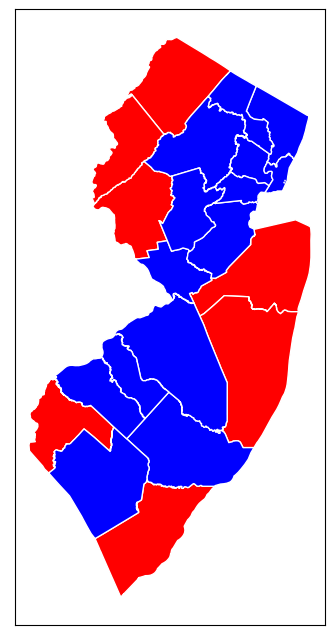

saving figure
ok


In [8]:
# print('getting from backup...')
# data_gdf = data_gdf_bk
fig, ax = plt.subplots(1,1, figsize=(12,8))
print('plotting election results...')
data_gdf[data_gdf['rep_win'] == True].plot(ax=ax, color='red', edgecolor='white')
data_gdf[data_gdf['dem_win'] == True].plot(ax=ax, color='blue', edgecolor='white')
# for ix, thisrow in data_gdf[data_gdf['NAMELSAD'].isnull()].iterrows():
#     annotation = thisrow['Locality']
#     print(annotation)
# print('plotting water areas...')
# water_gdf.plot(ax=ax, color='white')
ax.set_xticks([])
ax.set_yticks([])

plt.show()
print('saving figure')
fig.savefig('newjersey-election-2025-unscaled.svg', format='svg')
print('ok')

In [9]:
# Scale
print('getting from backup...')
data_gdf = data_gdf_bk

print('scaling...')
mean_votes = data_gdf['Total votes'].mean()
data_gdf = data_gdf.assign(scale_factor = data_gdf['Total votes'] * (mean_votes / data_gdf.to_crs(equalareacrs).geometry.area))
data_gdf = data_gdf.assign(new_geometry = data_gdf.apply(lambda row: affinity.scale(row['geometry'], row['scale_factor'], row['scale_factor']), axis=1))
data_gdf = data_gdf.set_geometry(data_gdf['new_geometry'])
print('Done!')


getting from backup...
scaling...
Done!


# ALL

saving figure
ok


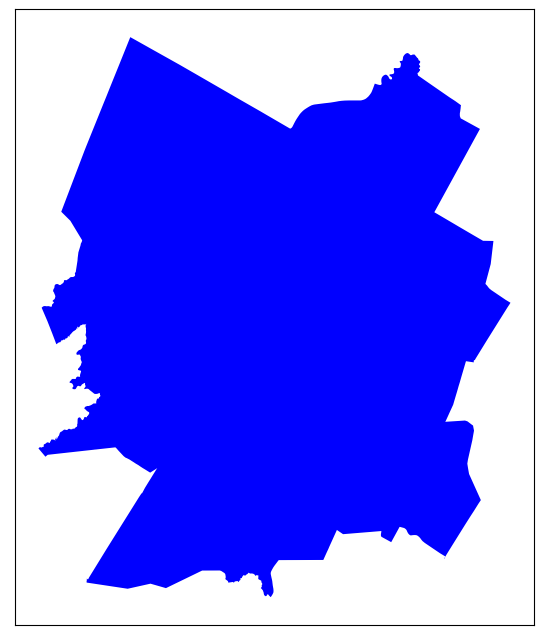

In [13]:
saveit = True
fig, ax = plt.subplots(1,1, figsize=(12,8))
data_gdf[(data_gdf['rep_win'] == True)].plot(ax=ax, color='red')
data_gdf[(data_gdf['dem_win'] == True)].plot(ax=ax, color='blue')
ax.set_xticks([])
ax.set_yticks([])

if (saveit):
    print('saving figure')
    plt.savefig('newjersey-election-2025-rescaled.svg', format='svg')
else:
    plt.show()
print('ok')
#data_gdf[data_gdf['NAMELSAD'].isin(county_list)]